# Step 3 - Clustering

In this step, I applied unsupervised clustering to identify spatial regions in the breast cancer tissue based on gene expression patterns.

The workflow included:

1. Scaling the normalized expression matrix
2. Principal component analysis
3. Construction of a nearest-neighbor graph
4. UMAP visualization
5. Leiden clustering
6. Spatial projection of clusters onto the tissue image

The resulting clusters represent transcriptionally similar tissue spots. Biological interpretation requires marker gene analysis in the next step.

## Load h5ad from Step 2


In [11]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt

adata = sc.read_h5ad("../data/processed/breast_cancer_visium_qc.h5ad")
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 3798 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'pca', 'spatial'
    obsm: 'X_pca', 'spatial'
    varm: 'PCs'

## 1. Scale the data


In [13]:
sc.pp.scale(adata, max_value=10, zero_center=False)

## 2. Run PCA

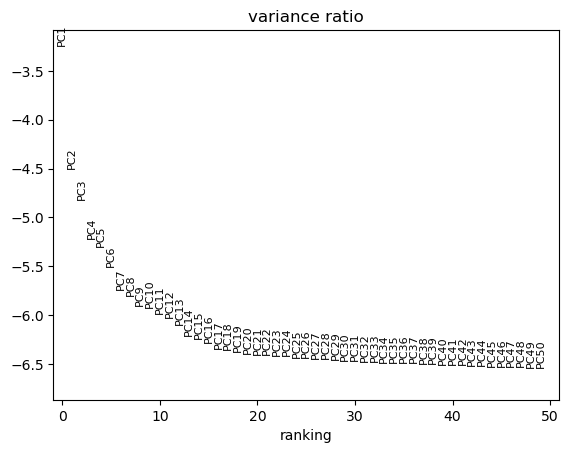

In [14]:
sc.tl.pca(adata, svd_solver="arpack")
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

## 3. Build neighborhood graph


In [15]:
sc.pp.neighbors(
    adata,
    n_neighbors=10,
    n_pcs=30
)

## 4. Run UMAP

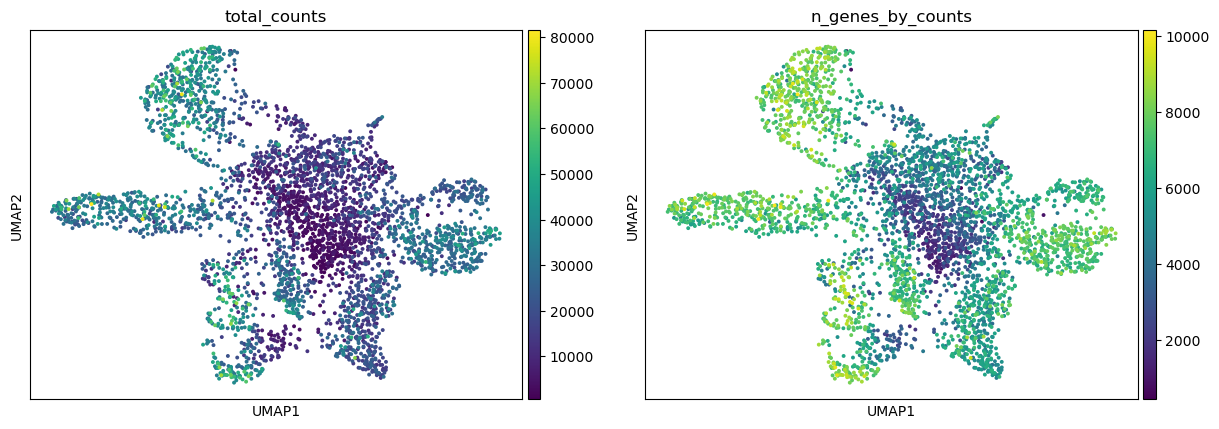

In [16]:
sc.tl.umap(adata)

sc.pl.umap(
    adata,
    color=["total_counts", "n_genes_by_counts"]
)

## 5. Run Leiden clustering

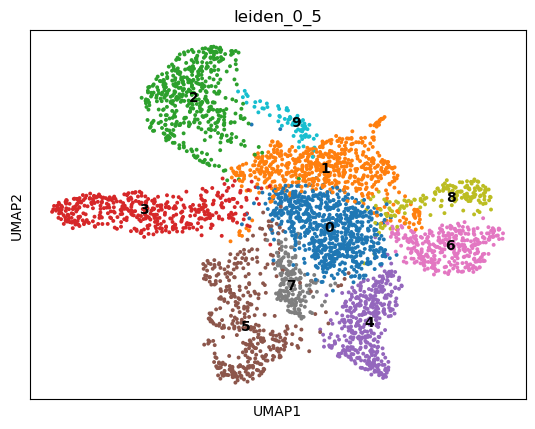

In [17]:
sc.tl.leiden(
    adata,
    resolution=0.5,
    key_added="leiden_0_5"
)

sc.pl.umap(
    adata,
    color="leiden_0_5",
    legend_loc="on data"
)

## Compare Leiden resolutions

Run clustering at several resolutions, then compare cluster granularity on UMAP.

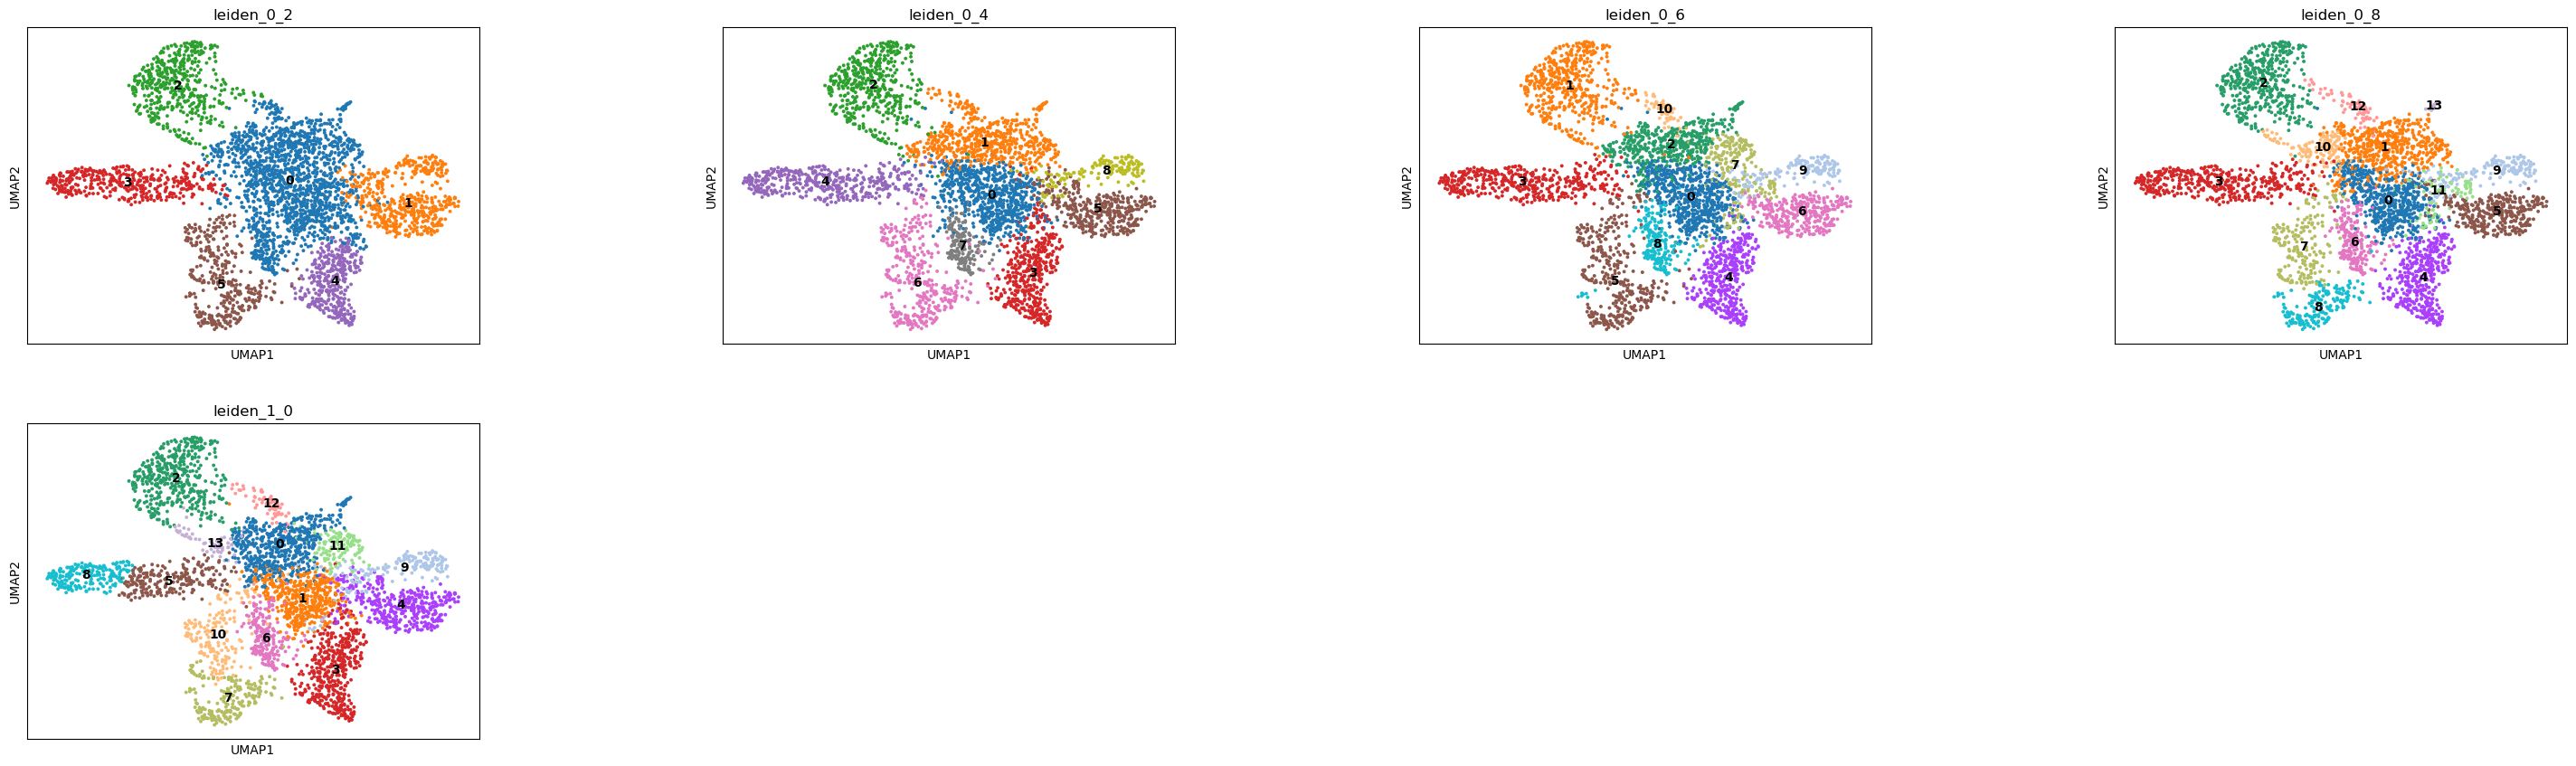

In [18]:
def leiden_key(resolution: float) -> str:
    return f"leiden_{resolution}".replace(".", "_")

compare_resolutions = [0.2, 0.4, 0.6, 0.8, 1.0]

for resolution in compare_resolutions:
    sc.tl.leiden(adata, resolution=resolution, key_added=leiden_key(resolution))

compare_keys = [leiden_key(r) for r in compare_resolutions]

sc.pl.umap(
    adata,
    color=compare_keys,
    legend_loc="on data",
    wspace=0.4,
)

## 6. Plot clusters on tissue image

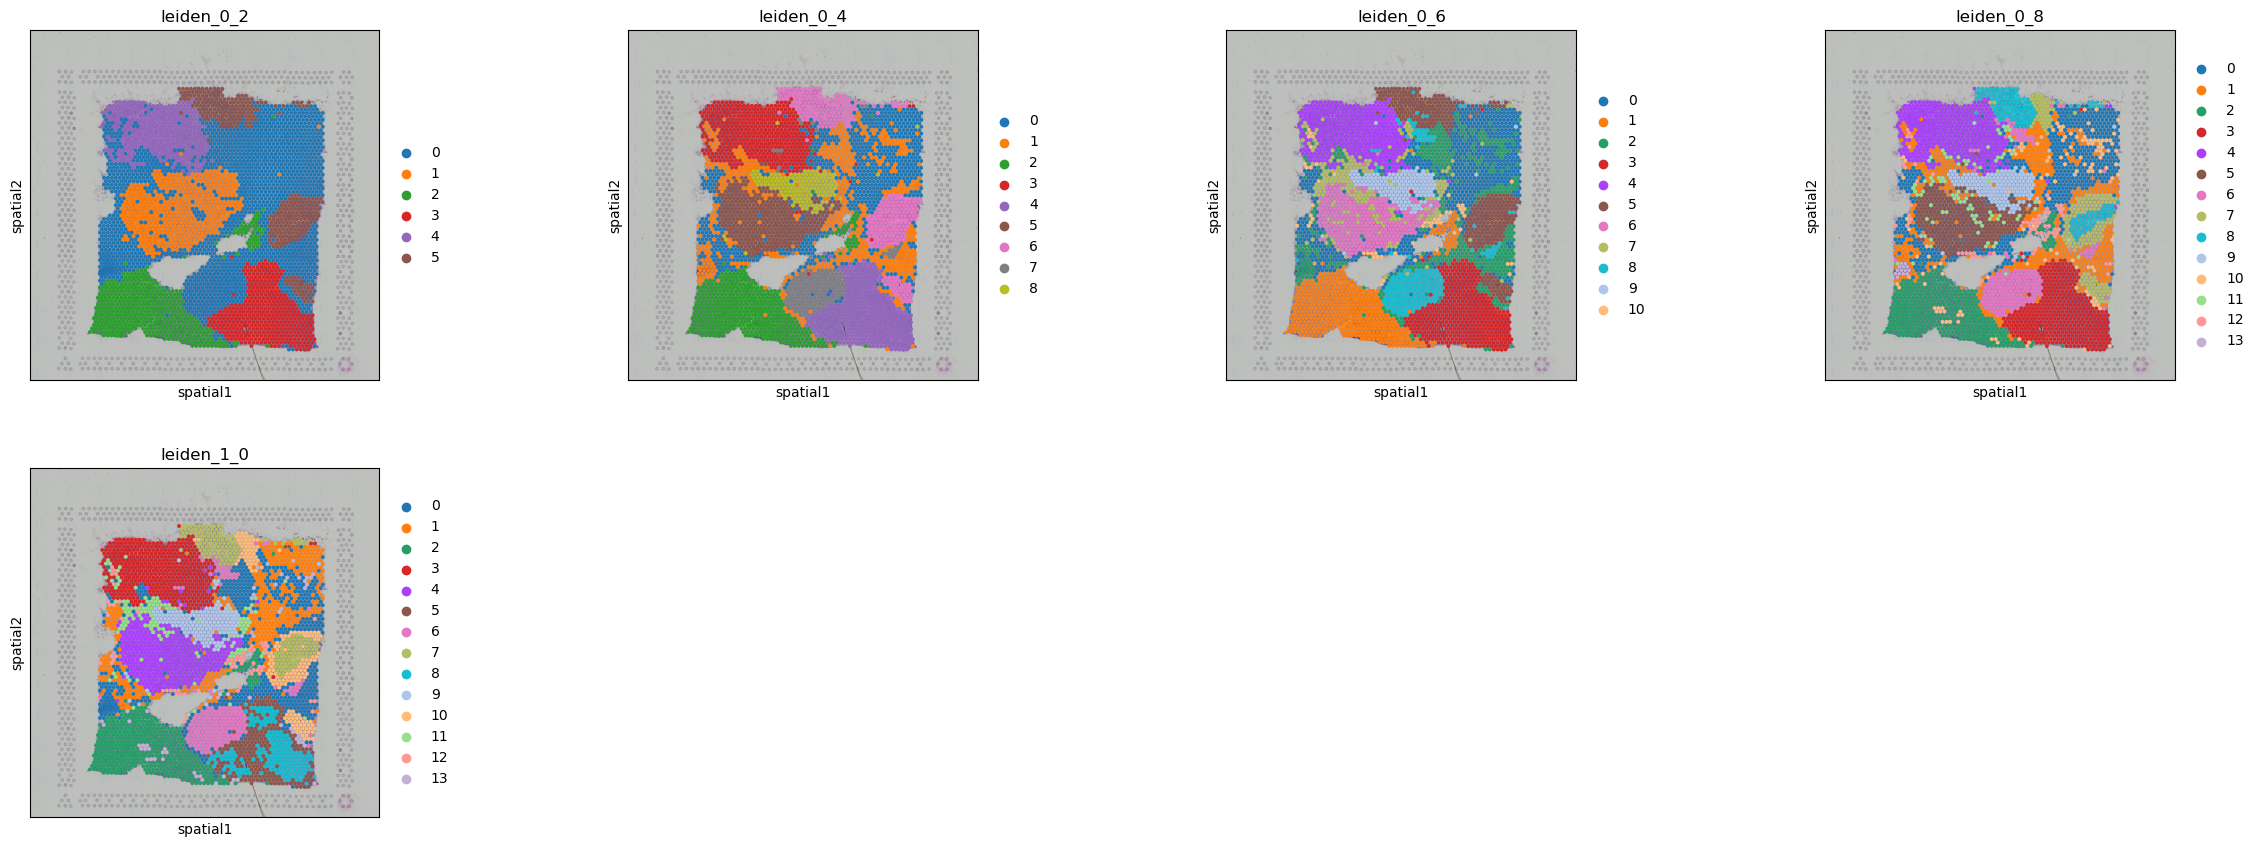

In [27]:
sq.pl.spatial_scatter(
    adata, 
    color=compare_keys, 
    size=1.5
)

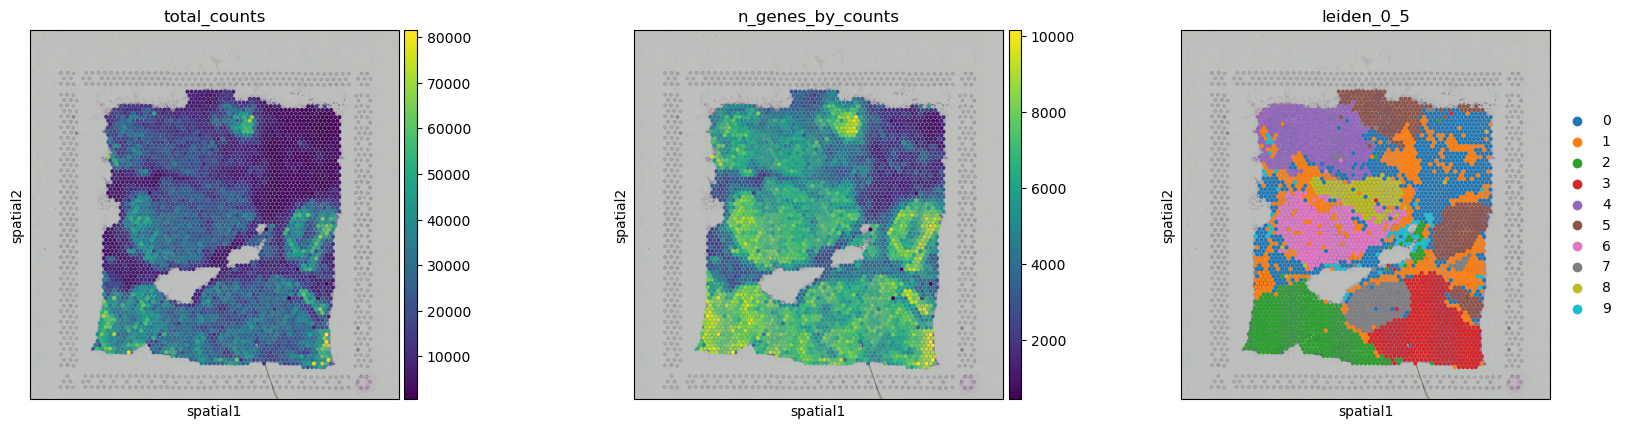

In [29]:
sq.pl.spatial_scatter(
    adata,
    color=["total_counts", "n_genes_by_counts", "leiden_0_5"],
    size=1.5
)

## 7. Interpret clusters


Cluster 1 is a gene-expression-defined spatial region. Next, I will use marker genes to infer whether it is tumor-like, immune-like, or stromal-like.

## 8. Save result

In [30]:
adata.write("../data/processed/breast_cancer_visium_clustered.h5ad")